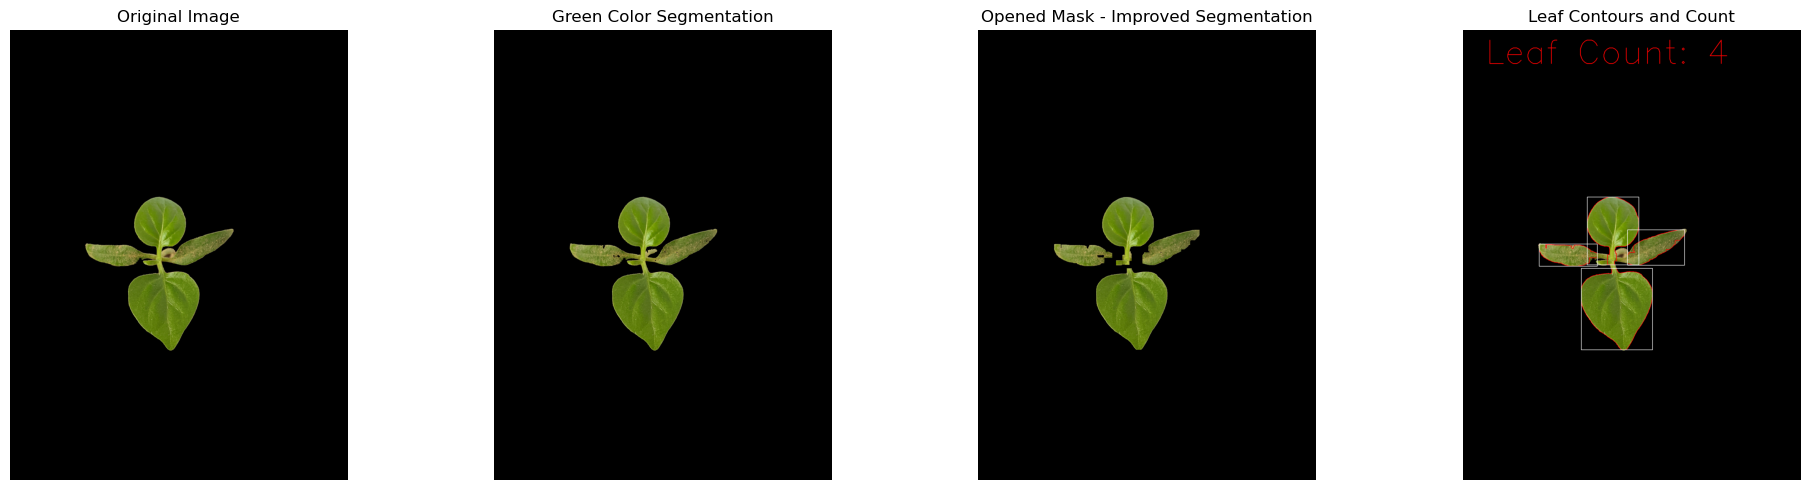

Total Leaf Count: 4


In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def process_plant_image(image_path):
    # Load the image
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Convert image to HSV and create mask for green color
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    lower_green = np.array([25, 40, 40])  # Adjust based on plant color
    upper_green = np.array([90, 255, 255])
    green_mask = cv2.inRange(hsv, lower_green, upper_green)
    green_segmented = cv2.bitwise_and(image_rgb, image_rgb, mask=green_mask)

    # Define a kernel for morphological operations
    kernel = np.ones((45, 45), np.uint8)  # Changed kernel to ones for proper morphology

    # Apply morphological opening to break narrow connections
    mask_opened = cv2.morphologyEx(green_mask, cv2.MORPH_OPEN, kernel)  # Applied on mask instead of segmented image
    final_segmented = cv2.bitwise_and(image_rgb, image_rgb, mask=mask_opened)

    # Find contours of leaves
    contours, _ = cv2.findContours(mask_opened, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE) #finding contour in mask_opened

    # Filter contours based on area to remove small noise
    min_leaf_area = 5000  # Adjust based on leaf size
    leaf_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > min_leaf_area]

    # Draw contours and bounding rectangles on the original image
    result = image.copy()
    cv2.drawContours(result, leaf_contours, -1, (0, 0, 255), 3)

    for cnt in leaf_contours:
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(result, (x, y), (x + w, y + h), (255, 255, 255), 3)  # white bounding box

    # Display leaf count
    leaf_count = len(leaf_contours)
    cv2.putText(result, f"Leaf Count: {leaf_count}", (200, 300),
                cv2.FONT_HERSHEY_SIMPLEX, 10, (0, 0, 255), 5)

    # Display the results
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes[0].imshow(image_rgb)
    axes[0].set_title("Original Image")
    axes[1].imshow(green_segmented)
    axes[1].set_title("Green Color Segmentation")
    axes[2].imshow(final_segmented)
    axes[2].set_title("Opened Mask - Improved Segmentation")
    axes[3].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB)) # Convert BGR to RGB for matplotlib
    axes[3].set_title("Leaf Contours and Count")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout() #added to prevent overlapping titles.
    plt.show()

    print(f"Total Leaf Count: {leaf_count}")

# calling the function with an image path
image_path = "img2/largest_green_masked_image.jpg"  # Replace with your image path
process_plant_image(image_path)
